# 3. Analisys

## 0. Import

In [2]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np

from src.clean_demo import clean_demo
from src.clean_drug import clean_drug
from src.clean_reac import clean_reac
from src.clean_outc import clean_outc
from src.clean_indi import clean_indi
from src.map_atc import annotate_atc

from src.utils import rename_columns, normalize_str_values, standardize_unknown, fill_str_nulls, convert_str_to_cat, drop_duplicates

In [3]:
DATA_PATH = '/Users/welcome/Desktop/csv/faers_ascii_2024q2/ASCII/'

DEMO_FILE = DATA_PATH + 'DEMO24Q2.txt'
DRUG_FILE = DATA_PATH + 'DRUG24Q2.txt'
REAC_FILE = DATA_PATH + 'REAC24Q2.txt'
OUTC_FILE = DATA_PATH + 'OUTC24Q2.txt'
INDI_FILE = DATA_PATH + 'INDI24Q2.txt'

In [4]:
df_demo = pd.read_csv(DEMO_FILE, sep='$', low_memory=False)
df_demo = clean_demo(df_demo)

df_drug = pd.read_csv(DRUG_FILE, sep='$', low_memory=False)
df_drug = clean_drug(df_drug)

df_out = pd.read_csv(OUTC_FILE, sep='$', low_memory=False)
df_out = clean_outc(df_out)

df_reac = pd.read_csv(REAC_FILE, sep='$', low_memory=False)
df_reac = clean_reac(df_reac)

df_indi = pd.read_csv(INDI_FILE, sep='$', low_memory=False)
df_indi = clean_indi(df_indi)

In [5]:
df_drug = annotate_atc(
    df_drug,
    name_col='prod_ai',
    cache_prod_ai_path='../data/atc/rxnav_atc_cache.json',
    cache_drugname_path='../data/atc/rxnav_atc_cache_drugname.json',
    drugcentral_path='../data/atc/drugcentral_inn.tsv',
)


str_cols = df_drug.select_dtypes('str').columns.tolist()
df_drug[str_cols] = df_drug[str_cols].fillna('UNK')

df_drug.head()

,primaryid,caseid,drug_seq,role_cod,drugname,prod_ai,prod_ai_clean,route,dose_form,is_primary,drugs_per_case,atc_by_ai,atc_by_name,atc_final,atc_matched,atc_final_norm
0,39649924,3964992,1,PS,CYCLOSPORINE,CYCLOSPORINE,CYCLOSPORINE,INTRAVENOUS (NOT OTHERWISE SPECIFIED),UNK,True,5,Calcineurin inhibitors,Calcineurin inhibitors,Calcineurin inhibitors,True,CALCINEURIN INHIBITORS
1,39649924,3964992,2,SS,METHOTREXATE,METHOTREXATE,METHOTREXATE,INTRATHECAL,UNK,False,5,Folic acid analogues,Folic acid analogues,Folic acid analogues,True,FOLIC ACID ANALOGUES
2,39649924,3964992,4,SS,CYCLOPHOSPHAMIDE,CYCLOPHOSPHAMIDE,CYCLOPHOSPHAMIDE,UNK,UNK,False,5,Nitrogen mustard analogues,Nitrogen mustard analogues,Nitrogen mustard analogues,True,NITROGEN MUSTARD ANALOGUES
3,39649924,3964992,5,SS,VINCRISTINE SULFATE,VINCRISTINE SULFATE,VINCRISTINE,UNK,UNK,False,5,Vinca alkaloids and analogues,Vinca alkaloids and analogues,Vinca alkaloids and analogues,True,VINCA ALKALOIDS AND ANALOGUES
4,39649924,3964992,6,SS,CYTARABINE,CYTARABINE,CYTARABINE,INTRATHECAL,UNK,False,5,Combinations of antineoplastic agents,Combinations of antineoplastic agents,Combinations of antineoplastic agents,True,COMBINATIONS OF ANTINEOPLASTIC AGENTS


In [6]:
from src.clean_atc import clean_atc

df_atc = pd.read_csv('../data/atc/who_atc_ddd_2026_2026-02-23.csv')
df_atc = clean_atc(df_atc)

df_drug = df_drug.merge(
    df_atc[['atc4_description', 'atc2_description']].drop_duplicates(),
    left_on='atc_final_norm',
    right_on='atc4_description',
    how='left'
)

df_drug['atc2_description'] = df_drug['atc2_description'].fillna('UNK')
df_drug['atc4_description'] = df_drug['atc4_description'].fillna('UNK')

print(df_drug.isna().sum())

primaryid           0
caseid              0
drug_seq            0
role_cod            0
drugname            0
prod_ai             0
prod_ai_clean       0
route               0
dose_form           0
is_primary          0
drugs_per_case      0
atc_by_ai           0
atc_by_name         0
atc_final           0
atc_matched         0
atc_final_norm      0
atc4_description    0
atc2_description    0
dtype: int64


## 1.Which drugs are associated with the highest number of serious adverse events?

In [7]:
df = pd.merge(df_drug, df_out, how='inner', on=['primaryid', 'caseid'])

In [8]:
solo = df[df['drugs_per_case'] == 1]
multi = df[df['is_primary']]

In [9]:
top_by_solo_adverse = solo.groupby('drugname', as_index=False).agg(n_cases = ('caseid', 'nunique'))\
    .sort_values('n_cases', ascending=False)

top10_solo = top_by_solo_adverse.head(10)
top10_solo

,drugname,n_cases
2613,SKYRIZI,2677
2471,RINVOQ,2367
1376,HUMIRA,2343
941,DUPIXENT,1667
976,ELIQUIS,1544
2447,REVLIMID,1511
2995,VEDOLIZUMAB,1372
1658,LENALIDOMIDE,1154
664,CLOZAPINE,1077
2433,REMICADE,1000


In [10]:
top_by_multi_adverse = multi.groupby('drugname', as_index=False).agg(n_cases_all_ps = ('caseid', 'nunique'))\
    .sort_values('n_cases_all_ps', ascending=False)

top10_multi = top_by_multi_adverse.head(10)
top10_multi

,drugname,n_cases_all_ps
3723,VEDOLIZUMAB,4565
3281,SKYRIZI,3402
1757,HUMIRA,3391
3113,RINVOQ,3190
1207,DUPIXENT,2539
1871,INFLECTRA,2428
2316,METHOTREXATE,2264
3087,REVLIMID,2207
2019,KEYTRUDA,2197
1250,ELIQUIS,2069


In [11]:
top_solo_group = solo.groupby('atc_final', as_index=False).agg(n_cases = ('caseid', 'nunique'))\
    .sort_values('n_cases', ascending=False)
top_solo_group = top_solo_group[top_solo_group['atc_final'] != 'UNK']

top10_solo_group = top_solo_group.head(10)
top10_solo_group

,atc_final,n_cases
387,Tumor necrosis factor alpha (TNF-alpha) inhibi...,8383
182,Interleukin inhibitors,5557
283,Other immunosuppressants,4046
189,Janus-associated kinase (JAK) inhibitors,3663
203,Monoclonal antibodies,3306
9,"Agents for dermatitis, excluding corticosteroids",2750
119,"Diazepines, oxazepines, thiazepines and oxepines",2318
304,PD-1/PD-L1 (Programmed cell death protein 1/de...,2301
126,Direct factor Xa inhibitors,2278
247,Other antineoplastic agents,1568


In [12]:
top_multi_group = multi.groupby('atc_final', as_index=False).agg(n_cases = ('caseid', 'nunique'))\
    .sort_values('n_cases', ascending=False)
top_multi_group = top_multi_group[top_multi_group['atc_final'] != 'UNK']

top10_multi_group = top_multi_group.head(10)
top10_multi_group

,atc_final,n_cases
416,Tumor necrosis factor alpha (TNF-alpha) inhibi...,14512
195,Interleukin inhibitors,8343
223,Monoclonal antibodies,8009
327,PD-1/PD-L1 (Programmed cell death protein 1/de...,6283
306,Other immunosuppressants,5980
204,Janus-associated kinase (JAK) inhibitors,5390
10,"Agents for dermatitis, excluding corticosteroids",5177
126,"Diazepines, oxazepines, thiazepines and oxepines",4037
82,CD20 (Clusters of Differentiation 20) inhibitors,3811
165,Folic acid analogues,3635


## 2.Which drugs are most frequently linked to death outcomes?

In [13]:
solo_dth = solo[solo['outc_cod'] == 'DE']
multi_dth = multi[multi['outc_cod'] == 'DE']

In [14]:
solo_dth_drg = solo_dth.groupby('drugname', as_index=False).agg(n_cases = ('caseid', 'nunique'))\
    .sort_values('n_cases', ascending=False)

solo_dth_drg_top = solo_dth_drg.head(10)
solo_dth_drg_top

,drugname,n_cases
341,ELIQUIS,478
403,FARXIGA,437
1042,TAGRISSO,292
205,CARBIDOPA\LEVODOPA,235
1183,VENCLEXTA,213
498,HUMIRA,211
340,ELIGARD,211
767,NUPLAZID,209
1059,TECENTRIQ,196
924,REVLIMID,188


In [15]:
multi_dth_drg = multi_dth.groupby('drugname', as_index=False).agg(n_cases = ('caseid', 'nunique'))\
    .sort_values('n_cases', ascending=False)

multi_dth_drg_top = multi_dth_drg.head(10)
multi_dth_drg_top

,drugname,n_cases
537,ELIQUIS,625
628,FARXIGA,448
887,KEYTRUDA,398
1151,NUPLAZID,377
1705,VENCLEXTA,373
309,CARBIDOPA\LEVODOPA,325
1544,TECENTRIQ,322
1521,TAGRISSO,311
1392,RITUXIMAB,283
1374,REVLIMID,271


In [16]:
solo_dth_grp = solo_dth.groupby('atc_final', as_index=False).agg(n_cases=('caseid', 'nunique')) \
    .sort_values('n_cases', ascending=False)
solo_dth_grp = solo_dth_grp[solo_dth_grp['atc_final'] != 'UNK']
solo_dth_grp_top = solo_dth_grp.head(10)
solo_dth_grp_top

,atc_final,n_cases
206,PD-1/PD-L1 (Programmed cell death protein 1/de...,730
191,Other immunosuppressants,569
84,Direct factor Xa inhibitors,534
240,Sodium-glucose co-transporter 2 (SGLT2) inhibi...,530
168,Other antineoplastic agents,416
253,Tumor necrosis factor alpha (TNF-alpha) inhibi...,411
195,Other nervous system drugs,393
199,Other protein kinase inhibitors,385
97,Epidermal growth factor receptor (EGFR) tyrosi...,326
110,Gonadotropin releasing hormone analogues,321


In [17]:
multi_dth_grp = multi_dth.groupby('atc_final', as_index=False).agg(n_cases = ('caseid', 'nunique'))\
    .sort_values('n_cases', ascending=False)
multi_dth_grp = multi_dth_grp[multi_dth_grp['atc_final'] != 'UNK']
multi_dth_grp_top = multi_dth_grp.head(10)
multi_dth_grp_top

,atc_final,n_cases
250,PD-1/PD-L1 (Programmed cell death protein 1/de...,1455
233,Other immunosuppressants,810
102,Direct factor Xa inhibitors,736
207,Other antineoplastic agents,727
312,Tumor necrosis factor alpha (TNF-alpha) inhibi...,688
236,Other monoclonal antibodies and antibody drug ...,637
295,Sodium-glucose co-transporter 2 (SGLT2) inhibi...,603
242,Other protein kinase inhibitors,601
153,Interleukin inhibitors,527
96,"Diazepines, oxazepines, thiazepines and oxepines",503


## 3.Which drug combinations are the most dangerous?

In [18]:
df_mlty = df[df['drugs_per_case'] > 1]

df_case_drugs = (
    df_mlty.sort_values('prod_ai')
    .groupby('caseid', as_index=False)['prod_ai']
    .agg(lambda x: ', '.join(sorted(set(x))))
    .rename(columns={'prod_ai': 'drugs_comb'})
)

In [19]:
df_case_drugs

,caseid,drugs_comb
0,3964992,"CYCLOPHOSPHAMIDE, CYCLOSPORINE, CYTARABINE, ME..."
1,6100349,"CANDESARTAN CILEXETIL\HYDROCHLOROTHIAZIDE, LEF..."
2,6252184,"AMPICILLIN, AZITHROMYCIN, BETHANECHOL, CEFOTAX..."
3,6331994,"CEFTRIAXONE SODIUM, CIPROFLOXACIN, FLUINDIONE,..."
4,6333710,"CEFTRIAXONE SODIUM, CIPROFLOXACIN HYDROCHLORID..."
...,...,...
116893,24036509,"AMLODIPINE BESYLATE, ATENOLOL, ESZOPICLONE, LE..."
116894,24036556,"FLUOXETINE HYDROCHLORIDE, GLIPIZIDE, METFORMIN..."
116895,24036579,"MAGNESIUM, SEMAGLUTIDE, VITAMIN D NOS"
116896,24036580,"PALIPERIDONE PALMITATE, QUETIAPINE FUMARATE"


In [20]:
df_case_drugs.groupby('drugs_comb', as_index=False).agg(n_cases = ('caseid', 'nunique'))\
    .sort_values('n_cases', ascending=False).head(10)

,drugs_comb,n_cases
70911,"IPILIMUMAB, NIVOLUMAB",661
71799,"LENVATINIB, PEMBROLIZUMAB",491
71765,"LENVATINIB MESYLATE, PEMBROLIZUMAB",447
52078,"CARBOPLATIN, PACLITAXEL, PEMBROLIZUMAB",389
38545,"ATEZOLIZUMAB, BEVACIZUMAB",371
40813,"AZACITIDINE, VENETOCLAX",229
75651,"PREDNISONE, VEDOLIZUMAB",215
71889,"LETROZOLE, RIBOCICLIB",213
76456,VEDOLIZUMAB,211
59659,"DABRAFENIB MESYLATE, TRAMETINIB DIMETHYL SULFO...",180


In [21]:
df_case_drugs[df_case_drugs['drugs_comb'] == 'VEDOLIZUMAB']

,caseid,drugs_comb
639,13537377,VEDOLIZUMAB
681,13674219,VEDOLIZUMAB
3754,18083545,VEDOLIZUMAB
4411,18440294,VEDOLIZUMAB
5228,18870455,VEDOLIZUMAB
...,...,...
113894,24014873,VEDOLIZUMAB
114455,24017464,VEDOLIZUMAB
115033,24019738,VEDOLIZUMAB
115770,24027879,VEDOLIZUMAB


In [22]:
df_case_drugs['drugs_comb_list'] = df_case_drugs['drugs_comb'].str.split(', ')
df_case_drugs['n_unique_drugs'] = df_case_drugs['drugs_comb_list'].apply(lambda x: len(x))
df_case_drugs = df_case_drugs[df_case_drugs['n_unique_drugs'] > 1]

In [23]:
df_case_drugs.groupby('drugs_comb', as_index=False).agg(n_cases = ('caseid', 'nunique'))\
    .sort_values('n_cases', ascending=False).head(10)

,drugs_comb,n_cases
70858,"IPILIMUMAB, NIVOLUMAB",661
71741,"LENVATINIB, PEMBROLIZUMAB",491
71707,"LENVATINIB MESYLATE, PEMBROLIZUMAB",447
52055,"CARBOPLATIN, PACLITAXEL, PEMBROLIZUMAB",389
38530,"ATEZOLIZUMAB, BEVACIZUMAB",371
40798,"AZACITIDINE, VENETOCLAX",229
75574,"PREDNISONE, VEDOLIZUMAB",215
71831,"LETROZOLE, RIBOCICLIB",213
59632,"DABRAFENIB MESYLATE, TRAMETINIB DIMETHYL SULFO...",180
52052,"CARBOPLATIN, PACLITAXEL",175


In [24]:
df_drug

,primaryid,caseid,drug_seq,role_cod,drugname,prod_ai,prod_ai_clean,route,dose_form,is_primary,drugs_per_case,atc_by_ai,atc_by_name,atc_final,atc_matched,atc_final_norm,atc4_description,atc2_description
0,39649924,3964992,1,PS,CYCLOSPORINE,CYCLOSPORINE,CYCLOSPORINE,INTRAVENOUS (NOT OTHERWISE SPECIFIED),UNK,True,5,Calcineurin inhibitors,Calcineurin inhibitors,Calcineurin inhibitors,True,CALCINEURIN INHIBITORS,CALCINEURIN INHIBITORS,IMMUNOSUPPRESSANTS
1,39649924,3964992,2,SS,METHOTREXATE,METHOTREXATE,METHOTREXATE,INTRATHECAL,UNK,False,5,Folic acid analogues,Folic acid analogues,Folic acid analogues,True,FOLIC ACID ANALOGUES,FOLIC ACID ANALOGUES,ANTINEOPLASTIC AGENTS
2,39649924,3964992,4,SS,CYCLOPHOSPHAMIDE,CYCLOPHOSPHAMIDE,CYCLOPHOSPHAMIDE,UNK,UNK,False,5,Nitrogen mustard analogues,Nitrogen mustard analogues,Nitrogen mustard analogues,True,NITROGEN MUSTARD ANALOGUES,NITROGEN MUSTARD ANALOGUES,ANTINEOPLASTIC AGENTS
3,39649924,3964992,5,SS,VINCRISTINE SULFATE,VINCRISTINE SULFATE,VINCRISTINE,UNK,UNK,False,5,Vinca alkaloids and analogues,Vinca alkaloids and analogues,Vinca alkaloids and analogues,True,VINCA ALKALOIDS AND ANALOGUES,VINCA ALKALOIDS AND ANALOGUES,ANTINEOPLASTIC AGENTS
4,39649924,3964992,6,SS,CYTARABINE,CYTARABINE,CYTARABINE,INTRATHECAL,UNK,False,5,Combinations of antineoplastic agents,Combinations of antineoplastic agents,Combinations of antineoplastic agents,True,COMBINATIONS OF ANTINEOPLASTIC AGENTS,COMBINATIONS OF ANTINEOPLASTIC AGENTS,ANTINEOPLASTIC AGENTS
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1353441,19454468122,19454468,204,C,LOPERAMIDE,LOPERAMIDE,LOPERAMIDE,ORAL,UNK,False,133,Antipropulsives,Antipropulsives,Antipropulsives,True,ANTIPROPULSIVES,ANTIPROPULSIVES,"ANTIDIARRHEALS, INTESTINAL ANTIINFLAMMATORY/AN..."
1353442,19454468122,19454468,205,C,CALCIUM\ERGOCALCIFEROL,CALCIUM\ERGOCALCIFEROL,CALCIUM\ERGOCALCIFEROL,UNK,UNK,False,133,UNK,UNK,UNK,True,UNK,UNK,UNK
1353443,19454468122,19454468,207,C,POLYETHYLENE GLYCOLS,POLYETHYLENE GLYCOLS,POLYETHYLENE GLYCOLS,UNK,UNK,False,133,Osmotically acting laxatives,Osmotically acting laxatives,Osmotically acting laxatives,True,OSMOTICALLY ACTING LAXATIVES,OSMOTICALLY ACTING LAXATIVES,DRUGS FOR CONSTIPATION
1353444,19454468122,19454468,208,C,MUPIROCIN CALCIUM,MUPIROCIN CALCIUM,MUPIROCIN,UNK,UNK,False,133,Other antibiotics for topical use,Other antibiotics for topical use,Other antibiotics for topical use,True,OTHER ANTIBIOTICS FOR TOPICAL USE,OTHER ANTIBIOTICS FOR TOPICAL USE,ANTIBIOTICS AND CHEMOTHERAPEUTICS FOR DERMATOL...


In [25]:
df.columns

Index(['primaryid', 'caseid', 'drug_seq', 'role_cod', 'drugname', 'prod_ai',
       'prod_ai_clean', 'route', 'dose_form', 'is_primary', 'drugs_per_case',
       'atc_by_ai', 'atc_by_name', 'atc_final', 'atc_matched',
       'atc_final_norm', 'atc4_description', 'atc2_description', 'outc_cod',
       'outcome'],
      dtype='str')

In [26]:
df_multy = df[['primaryid', 'caseid', 'drug_seq', 'role_cod', 'drugname', 
        'prod_ai_clean', 'route', 'dose_form', 'is_primary', 'drugs_per_case',
        'atc_final_norm', 'atc2_description', 'outc_cod',
       'outcome']]

In [27]:
df_mlty = df_multy[df_multy['drugs_per_case'] > 1]

df_case_drugs = (
    df_mlty.sort_values('prod_ai_clean')
    .groupby('caseid', as_index=False)['prod_ai_clean']
    .agg(lambda x: ', '.join(sorted(set(x))))
    .rename(columns={'prod_ai_clean': 'drugs_comb'})
)

df_case_drugs['drugs_comb_list'] = df_case_drugs['drugs_comb'].str.split(', ')
df_case_drugs['n_unique_drugs'] = df_case_drugs['drugs_comb_list'].apply(len)
df_case_drugs = df_case_drugs[df_case_drugs['n_unique_drugs'] > 1]

df_case_drugs.groupby('drugs_comb', as_index=False).agg(n_cases=('caseid', 'nunique')) \
    .sort_values('n_cases', ascending=False).head(10)

,drugs_comb,n_cases
68765,"LENVATINIB, PEMBROLIZUMAB",938
67928,"IPILIMUMAB, NIVOLUMAB",661
50063,"CARBOPLATIN, PACLITAXEL, PEMBROLIZUMAB",389
37126,"ATEZOLIZUMAB, BEVACIZUMAB",371
39309,"AZACITIDINE, VENETOCLAX",229
57269,"DABRAFENIB, TRAMETINIB",218
72402,"PREDNISONE, VEDOLIZUMAB",215
68856,"LETROZOLE, RIBOCICLIB",214
50060,"CARBOPLATIN, PACLITAXEL",175
71110,"MYCOPHENOLATE MOFETIL, PREDNISONE, TACROLIMUS",173


## 4. Which adverse reactions are most common for specific drug classes?

In [28]:
df_sdc = df[['primaryid', 'caseid', 'drug_seq', 'role_cod', 'drugname', 
        'prod_ai_clean', 'route', 'dose_form', 'is_primary', 'drugs_per_case',
        'atc_final_norm', 'atc2_description', 'outc_cod',
       'outcome']]

In [29]:
df_sdc = df[['primaryid', 'caseid', 'prod_ai_clean', 'atc2_description']]

In [30]:
df_rctn = df_reac[['primaryid',	'caseid', 'pt']]

In [31]:
df_sdc = pd.merge(df_sdc, df_rctn, on=['primaryid', 'caseid'], how='inner')

In [32]:
df_sdc_grpd = df_sdc.groupby(['atc2_description', 'pt'], as_index=False).agg(n_cases = ('caseid', 'nunique'))

In [82]:
df_sdc_grpd

,atc2_description,pt,n_cases,rnk
0,AGENTS ACTING ON THE RENIN ANGIOTENSIN SYSTEM,5 HYDROXYINDOLACETIC ACID INCREASED,4,304
1,AGENTS ACTING ON THE RENIN ANGIOTENSIN SYSTEM,ABDOMINAL ABSCESS,6,302
2,AGENTS ACTING ON THE RENIN ANGIOTENSIN SYSTEM,ABDOMINAL ADHESIONS,3,305
3,AGENTS ACTING ON THE RENIN ANGIOTENSIN SYSTEM,ABDOMINAL CAVITY DRAINAGE,1,307
4,AGENTS ACTING ON THE RENIN ANGIOTENSIN SYSTEM,ABDOMINAL DISCOMFORT,644,29
...,...,...,...,...
266060,VITAMINS,XEROPHTHALMIA,1,307
266061,VITAMINS,YELLOW SKIN,3,305
266062,VITAMINS,ZIKA VIRUS INFECTION,1,307
266063,VITAMINS,ZOONOSIS,1,307


In [83]:
df_sdc_grpd = df_sdc_grpd[df_sdc_grpd['pt'] != 'OFF LABEL USE']

In [84]:
df_sdc_grpd

,atc2_description,pt,n_cases,rnk
0,AGENTS ACTING ON THE RENIN ANGIOTENSIN SYSTEM,5 HYDROXYINDOLACETIC ACID INCREASED,4,304
1,AGENTS ACTING ON THE RENIN ANGIOTENSIN SYSTEM,ABDOMINAL ABSCESS,6,302
2,AGENTS ACTING ON THE RENIN ANGIOTENSIN SYSTEM,ABDOMINAL ADHESIONS,3,305
3,AGENTS ACTING ON THE RENIN ANGIOTENSIN SYSTEM,ABDOMINAL CAVITY DRAINAGE,1,307
4,AGENTS ACTING ON THE RENIN ANGIOTENSIN SYSTEM,ABDOMINAL DISCOMFORT,644,29
...,...,...,...,...
266060,VITAMINS,XEROPHTHALMIA,1,307
266061,VITAMINS,YELLOW SKIN,3,305
266062,VITAMINS,ZIKA VIRUS INFECTION,1,307
266063,VITAMINS,ZOONOSIS,1,307


In [79]:
df_sdc_grpd['rnk'] = df_sdc_grpd.groupby('atc2_description')['n_cases'].rank(ascending=False, method='dense')\
    .astype('int')

In [88]:
df_sdc_grpd.sort_values(['atc2_description', 'rnk'], ascending=[True, True])

,atc2_description,pt,n_cases,rnk
1733,AGENTS ACTING ON THE RENIN ANGIOTENSIN SYSTEM,FATIGUE,1777,1
1347,AGENTS ACTING ON THE RENIN ANGIOTENSIN SYSTEM,DIARRHOEA,1439,2
3191,AGENTS ACTING ON THE RENIN ANGIOTENSIN SYSTEM,NAUSEA,1386,3
2088,AGENTS ACTING ON THE RENIN ANGIOTENSIN SYSTEM,HEADACHE,1364,4
3476,AGENTS ACTING ON THE RENIN ANGIOTENSIN SYSTEM,PAIN,1359,5
...,...,...,...,...
266050,VITAMINS,WOUND NECROSIS,1,307
266056,VITAMINS,WRONG PRODUCT ADMINISTERED,1,307
266060,VITAMINS,XEROPHTHALMIA,1,307
266062,VITAMINS,ZIKA VIRUS INFECTION,1,307


In [94]:
df_sdc_grpd_top = df_sdc_grpd[df_sdc_grpd['rnk'] < 6]\
    .sort_values(['atc2_description', 'rnk'], ascending=[True, True])

In [95]:
df_sdc_grpd_top.head(30)

,atc2_description,pt,n_cases,rnk
1733,AGENTS ACTING ON THE RENIN ANGIOTENSIN SYSTEM,FATIGUE,1777,1
1347,AGENTS ACTING ON THE RENIN ANGIOTENSIN SYSTEM,DIARRHOEA,1439,2
3191,AGENTS ACTING ON THE RENIN ANGIOTENSIN SYSTEM,NAUSEA,1386,3
2088,AGENTS ACTING ON THE RENIN ANGIOTENSIN SYSTEM,HEADACHE,1364,4
3476,AGENTS ACTING ON THE RENIN ANGIOTENSIN SYSTEM,PAIN,1359,5
5963,ALL OTHER THERAPEUTIC PRODUCTS,DYSPNOEA,435,1
5880,ALL OTHER THERAPEUTIC PRODUCTS,DIARRHOEA,323,2
6890,ALL OTHER THERAPEUTIC PRODUCTS,NAUSEA,303,3
5805,ALL OTHER THERAPEUTIC PRODUCTS,DEATH,275,4
6098,ALL OTHER THERAPEUTIC PRODUCTS,FATIGUE,275,4


In [98]:
df_sdc.head()

,primaryid,caseid,prod_ai_clean,atc2_description,pt
0,39649924,3964992,CYCLOSPORINE,IMMUNOSUPPRESSANTS,VISUAL IMPAIRMENT
1,39649924,3964992,CYCLOSPORINE,IMMUNOSUPPRESSANTS,HYPERTENSION
2,39649924,3964992,CYCLOSPORINE,IMMUNOSUPPRESSANTS,DEMYELINATION
3,39649924,3964992,CYCLOSPORINE,IMMUNOSUPPRESSANTS,TOXIC ENCEPHALOPATHY
4,39649924,3964992,CYCLOSPORINE,IMMUNOSUPPRESSANTS,GENERALISED TONIC CLONIC SEIZURE


### 4.1 PRR-based signal detection for drug class → reaction analysis

In [141]:
df_grpd_wo_rnk = df_sdc_grpd.copy()
df_grpd_wo_rnk = df_grpd_wo_rnk.drop('rnk', axis=1)

df_grpd_wo_rnk = df_grpd_wo_rnk.rename(columns={
    'atc2_description': 'drug_class',
    'pt': 'reaction'})

df_grpd_wo_rnk = df_grpd_wo_rnk[df_grpd_wo_rnk['n_cases'] >= 3]

In [142]:
df_grpd_wo_rnk['total_cases'] = df_grpd_wo_rnk['drug_class'].map(df_grpd_wo_rnk.groupby('drug_class')['n_cases'].sum())
# df_grpd_wo_rnk['cases_diff'] = df_grpd_wo_rnk['total_cases'] - df_grpd_wo_rnk['n_cases']

df_grpd_wo_rnk['reaction_n_cases'] = (
        df_grpd_wo_rnk['reaction'].map(df_grpd_wo_rnk.groupby('reaction')['n_cases'].sum()) - df_grpd_wo_rnk['n_cases']
)
df_grpd_wo_rnk['total_reations'] = (
    df_grpd_wo_rnk['n_cases'].sum() - df_grpd_wo_rnk['total_cases']
)
# df_grpd_wo_rnk['reactions_diff'] = df_grpd_wo_rnk['total_reations'] - df_grpd_wo_rnk['reaction_n_cases']

df_grpd_wo_rnk['coef'] = (
    (df_grpd_wo_rnk['n_cases'] / df_grpd_wo_rnk['total_cases']) /
    ((df_grpd_wo_rnk['reaction_n_cases'] + 0.5) / (df_grpd_wo_rnk['total_reations'] + 0.5))
)

df_grpd_wo_rnk['coef'] = df_grpd_wo_rnk['coef'].round(2)

In [143]:
df_grpd_wo_rnk.sort_values('coef', ascending=False).head(20)

,drug_class,reaction,n_cases,total_cases,reaction_n_cases,total_reations,coef
116798,CONTRAST MEDIA,CONTRAST ENCEPHALOPATHY,13,1645,0,5632849,89029.84
237461,THERAPEUTIC RADIOPHARMACEUTICALS,NEUROENDOCRINE TUMOUR OF THE RECTUM,3,739,0,5633755,45740.91
116800,CONTRAST MEDIA,CONTRAST MEDIA DEPOSITION,3,1645,0,5632849,20545.35
126810,"DIGESTIVES, INCL ENZYMES",CYSTIC FIBROSIS LUNG,7,4041,0,5630453,19506.64
126811,"DIGESTIVES, INCL ENZYMES",CYSTIC FIBROSIS PANCREATIC,7,4041,0,5630453,19506.64
112103,CALCIUM HOMEOSTASIS,HYPOCALCAEMIC SEIZURE,3,2383,0,5632111,14180.73
127433,"DIGESTIVES, INCL ENZYMES",PANCREATICODUODENECTOMY,4,4041,0,5630453,11146.65
127430,"DIGESTIVES, INCL ENZYMES",PANCREATIC OPERATION,4,4041,0,5630453,11146.65
127420,"DIGESTIVES, INCL ENZYMES",PANCREATIC CARCINOMA RECURRENT,3,4041,0,5630453,8359.99
164328,IMMUNE SERA AND IMMUNOGLOBULINS,RESPIRATORY SYNCYTIAL VIRUS BRONCHIOLITIS,25,1652,11,5632842,7412.42


## 5. Are there age or gender groups at higher risk of serious outcomes?

In [148]:
df_demo.head()

,primaryid,caseversion,rept_cod,mfr_dt,rept_dt,init_fda_dt,fda_dt,age_days,age_years,age_grp,sex,wt_kg,reporter_country,occr_country
0,100113073,3,EXP,2016-02-24,2024-06-25,2014-03-14,2024-06-25,16790.0,46.0,ADULT,F,NaN,CA,CA
1,1003229748,48,EXP,2024-05-22,2024-05-27,2014-03-24,2024-05-27,22265.0,61.0,ADULT,F,NaN,CA,CA
2,100373858,8,EXP,2024-04-30,2024-05-10,2014-03-26,2024-05-10,26280.0,72.0,ELDERLY,F,64.3,GB,GB
3,100445153,3,EXP,2024-04-29,2024-05-15,2014-03-28,2024-05-15,20075.0,55.0,ADULT,F,110.0,IT,IT
4,100789256,6,EXP,2024-03-22,2024-04-09,2014-04-15,2024-04-17,15330.0,42.0,ADULT,F,NaN,FR,FR


In [149]:
df_out.head()

,primaryid,caseid,outc_cod,outcome
0,1003229748,10032297,HO,HOSPITALIZATION
1,1003229748,10032297,OT,OTHER SERIOUS
2,100373858,10037385,OT,OTHER SERIOUS
3,100373858,10037385,DS,DISABILITY
4,100445153,10044515,OT,OTHER SERIOUS


In [150]:
df_age_sex_out = pd.merge(df_demo, df_out, on='primaryid', how='inner')
df_age_sex_out

,primaryid,caseversion,rept_cod,mfr_dt,rept_dt,init_fda_dt,fda_dt,age_days,age_years,age_grp,sex,wt_kg,reporter_country,occr_country,caseid,outc_cod,outcome
0,1003229748,48,EXP,2024-05-22,2024-05-27,2014-03-24,2024-05-27,22265.0,61.0,ADULT,F,NaN,CA,CA,10032297,HO,HOSPITALIZATION
1,1003229748,48,EXP,2024-05-22,2024-05-27,2014-03-24,2024-05-27,22265.0,61.0,ADULT,F,NaN,CA,CA,10032297,OT,OTHER SERIOUS
2,100373858,8,EXP,2024-04-30,2024-05-10,2014-03-26,2024-05-10,26280.0,72.0,ELDERLY,F,64.3,GB,GB,10037385,OT,OTHER SERIOUS
3,100373858,8,EXP,2024-04-30,2024-05-10,2014-03-26,2024-05-10,26280.0,72.0,ELDERLY,F,64.3,GB,GB,10037385,DS,DISABILITY
4,100445153,3,EXP,2024-04-29,2024-05-15,2014-03-28,2024-05-15,20075.0,55.0,ADULT,F,110.0,IT,IT,10044515,OT,OTHER SERIOUS
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
291445,987703854,54,EXP,2024-05-10,2024-05-17,2014-02-06,2024-05-17,<NA>,<NA>,UNK,F,99.0,CA,UNK,9877038,OT,OTHER SERIOUS
291446,98793582,2,EXP,2024-05-28,2024-05-31,2014-02-06,2024-05-31,22265.0,61.0,ADULT,F,NaN,AU,AU,9879358,DE,DEATH
291447,98803862,2,EXP,2024-03-22,2024-04-03,2014-02-07,2024-04-03,14235.0,39.0,ADULT,M,NaN,AU,AU,9880386,DE,DEATH
291448,98803862,2,EXP,2024-03-22,2024-04-03,2014-02-07,2024-04-03,14235.0,39.0,ADULT,M,NaN,AU,AU,9880386,OT,OTHER SERIOUS


In [154]:
df_age_sex_out['age_years'].describe()

count     197672.0
mean     56.170246
std      21.171738
min            0.0
25%           43.0
50%           60.0
75%           72.0
max          106.0
Name: age_years, dtype: Float64

<Axes: >

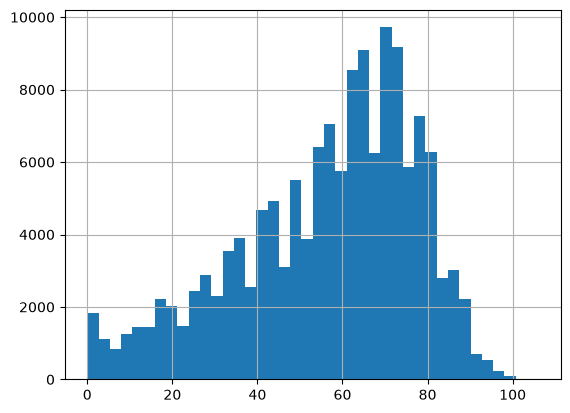

In [169]:
df_age_sex_out_fltrd = df_age_sex_out[['primaryid', 'age_years', 'sex', 'reporter_country']] \
    .drop_duplicates(subset='primaryid')

df_age_sex_out_fltrd['age_years'].hist(bins=40)

# df_age_sex_out['age_years'].hist(bins=40, )

In [174]:
df_age_sex_out_fltrd['age_years'].value_counts(ascending=False)\
    .head(20)

age_years
70.0    3699
65.0    3267
60.0    3156
68.0    3082
67.0    3072
72.0    3067
71.0    3039
74.0    3006
73.0    3002
75.0    2960
63.0    2939
66.0    2885
69.0    2875
64.0    2865
62.0    2833
76.0    2808
80.0    2802
77.0    2773
61.0    2712
59.0    2529
Name: count, dtype: Int64